In [ ]:
import os
from pathlib import Path

import h5py
import pandas as pd
import re


dirpath_root = Path(r'D:\WORK\Salvador\doc\Tuning\Allen_model')
os.chdir(dirpath_root)

# -------- helper: map pop_name → broad interneuron class ----------
def classify(pop_name: str) -> str:
    s = pop_name.lower()
    if 'pvalb' in s or re.search(r'\bpv', s):
        return 'PV'
    if 'sst' in s:
        return 'SST'
    if 'vip' in s or 'htr3a' in s:
        return 'VIP'
    return 'Pyr'                   # default: excitatory pyramidal

# -------- 1. load node-level metadata ------------------------------
nodes = pd.read_csv(
    'v1_nodes.csv',                # columns: id, pop_name, location, …
    delim_whitespace=True,
    usecols=['id', 'pop_name', 'location']
)
nodes['type']       = nodes['pop_name'].apply(classify)
nodes['population'] = nodes['location'] + '_' + nodes['type']

# number of cells in each population
cells_per_pop = nodes.groupby('population').size()

# quick gid → population lookup
gid_to_pop = dict(zip(nodes['id'], nodes['population']))

# -------- 2. load spike report -------------------------------------
with h5py.File('spikes.h5', 'r') as f:
    ts   = f['spikes']['v1']['timestamps'][...]   # float64, ms
    gids = f['spikes']['v1']['node_ids'][...]     # int64

spikes = pd.DataFrame({'gid': gids, 'time_ms': ts})
spikes['population'] = spikes['gid'].map(gid_to_pop)

#spikes = spikes[spikes['time_ms'] < 500]

# -------- 3. compute rates -----------------------------------------
spike_counts = spikes.groupby('population').size()
duration_sec = spikes['time_ms'].max() / 1000.0                   # ~3.0 s

rates_hz = (spike_counts / cells_per_pop) / duration_sec

# assemble final table
rates = pd.DataFrame({
    'layer'    : [p.split('_')[0] for p in rates_hz.index],
    'type'     : [p.split('_')[1] for p in rates_hz.index],
    'n_cells'  : cells_per_pop.values,
    'n_spikes' : spike_counts.values,
    'rate_Hz'  : rates_hz.values.round(3)
}).sort_values(['layer', 'type']).reset_index(drop=True)

print(rates)

C:\Users\aleks\AppData\Local\Temp\ipykernel_61500\2655413985.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  nodes = pd.read_csv(


ValueError: All arrays must be of the same length

In [19]:
print(spike_counts.index)
print(cells_per_pop.index)

Index(['VisL1_VIP', 'VisL23_PV', 'VisL23_Pyr', 'VisL23_SST', 'VisL23_VIP',
       'VisL4_PV', 'VisL4_Pyr', 'VisL4_SST', 'VisL4_VIP', 'VisL5_PV',
       'VisL5_Pyr', 'VisL5_SST', 'VisL6_PV', 'VisL6_Pyr', 'VisL6_SST',
       'VisL6_VIP'],
      dtype='object', name='population')
Index(['VisL1_VIP', 'VisL23_PV', 'VisL23_Pyr', 'VisL23_SST', 'VisL23_VIP',
       'VisL4_PV', 'VisL4_Pyr', 'VisL4_SST', 'VisL4_VIP', 'VisL5_PV',
       'VisL5_Pyr', 'VisL5_SST', 'VisL5_VIP', 'VisL6_PV', 'VisL6_Pyr',
       'VisL6_SST', 'VisL6_VIP'],
      dtype='object', name='population')


In [3]:
nodes

,id,pop_name,location,type,population
0,0,LIFe5Rbp4,VisL5,Pyr,VisL5_Pyr
1,1,LIFe5Rbp4,VisL5,Pyr,VisL5_Pyr
2,2,LIFe5Rbp4,VisL5,Pyr,VisL5_Pyr
3,3,LIFe5Rbp4,VisL5,Pyr,VisL5_Pyr
4,4,LIFe5Rbp4,VisL5,Pyr,VisL5_Pyr
...,...,...,...,...,...
230919,230919,LIFe6Ntsr1,VisL6,Pyr,VisL6_Pyr
230920,230920,LIFe6Ntsr1,VisL6,Pyr,VisL6_Pyr
230921,230921,LIFe6Ntsr1,VisL6,Pyr,VisL6_Pyr
230922,230922,LIFe6Ntsr1,VisL6,Pyr,VisL6_Pyr



File: D:\WORK\Salvador\doc\Tuning\Allen_model\spikes.trial_0.h5
LGN cells: 17383

segment                    spikes mean rate (Hz)
----------------------------------------------
grey_pre (0–0.5 s)          33660         3.87
stimulus (0.5–2.5 s)       242035         6.96
grey_post (2.5–3 s)         61951         7.13


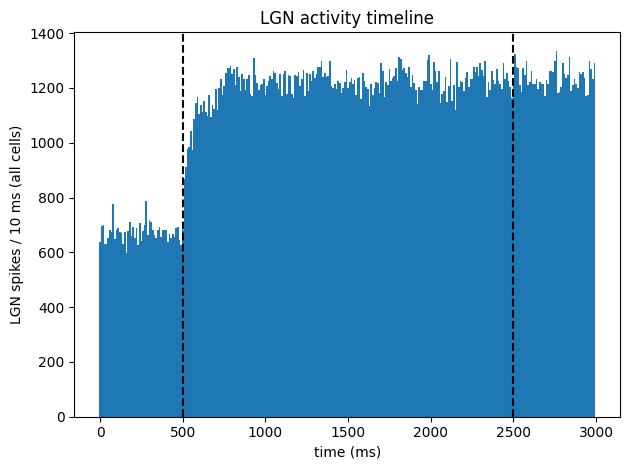

In [2]:
import argparse, h5py, numpy as np, textwrap, sys
import matplotlib.pyplot as plt

def load_spikes(h5file):
    """Return numpy arrays (timestamps_ms, node_ids)."""
    with h5py.File(h5file, 'r') as f:
        grp = f['spikes']['lgn']
        return grp['timestamps'][...], grp['node_ids'][...]

fpath_input = str(dirpath_root / 'spikes.trial_0.h5')
ts, gids = load_spikes(fpath_input)
duration_ms = ts.max()
n_cells = len(np.unique(gids))

segs = {
    'grey_pre (0–0.5 s)' : (0,    500),
    'stimulus (0.5–2.5 s)': (500, 2500),
    'grey_post (2.5–3 s)' : (2500, 3000),
}

print(f'\nFile: {fpath_input}\nLGN cells: {n_cells}\n')
print('{:<22} {:>10} {:>12}'.format('segment', 'spikes', 'mean rate (Hz)'))
print('-'*46)

for name, (t0, t1) in segs.items():
    mask = (ts >= t0) & (ts < t1)
    n_spikes = mask.sum()
    rate = n_spikes / n_cells / ((t1 - t0) / 1000.0)
    print(f'{name:<22} {n_spikes:>10} {rate:>12.2f}')

bins = np.arange(0, duration_ms + 10, 10)  # 10-ms bins
hist, _ = np.histogram(ts, bins=bins)
plt.bar(bins[:-1], hist, width=10)
plt.xlabel('time (ms)')
plt.ylabel('LGN spikes / 10 ms (all cells)')
plt.title('LGN activity timeline')
for t in (500, 2500):
    plt.axvline(t, color='k', linestyle='--')
plt.tight_layout()

C:\Users\aleks\AppData\Local\Temp\ipykernel_61500\536498621.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  nodes = pd.read_csv(


population  n_cells  overall_Hz  grey_pre_Hz  stimulus_Hz
 VisL1_VIP     4363    1.004206     0.458400     1.109328
 VisL23_PV     2927    2.875082     0.230368     3.314827
VisL23_Pyr    56057    0.545257     0.035015     0.636210
VisL23_SST     2120    0.631921     0.052561     0.738915
VisL23_VIP     4845    0.741592     0.251216     0.825387
  VisL4_PV     4461    9.701899     2.879559    10.977135
 VisL4_Pyr    45761    0.696433     0.068368     0.811248
 VisL4_SST     2384    1.698972     0.113854     1.962668
 VisL4_VIP     1231    1.379913     0.118371     1.615353
  VisL5_PV     2876    9.263945     2.185575    10.583449
 VisL5_Pyr    33558    2.401861     0.548815     2.734877
 VisL5_SST     2538    0.539797     0.007880     0.657013
 VisL5_VIP      508    0.812339     0.000000     0.943898
  VisL6_PV     4626    8.991389     1.267371    10.461198
 VisL6_Pyr    57202    1.992164     0.208085     2.322672
 VisL6_SST     4626    1.779226     0.020999     2.116840
 VisL6_VIP    

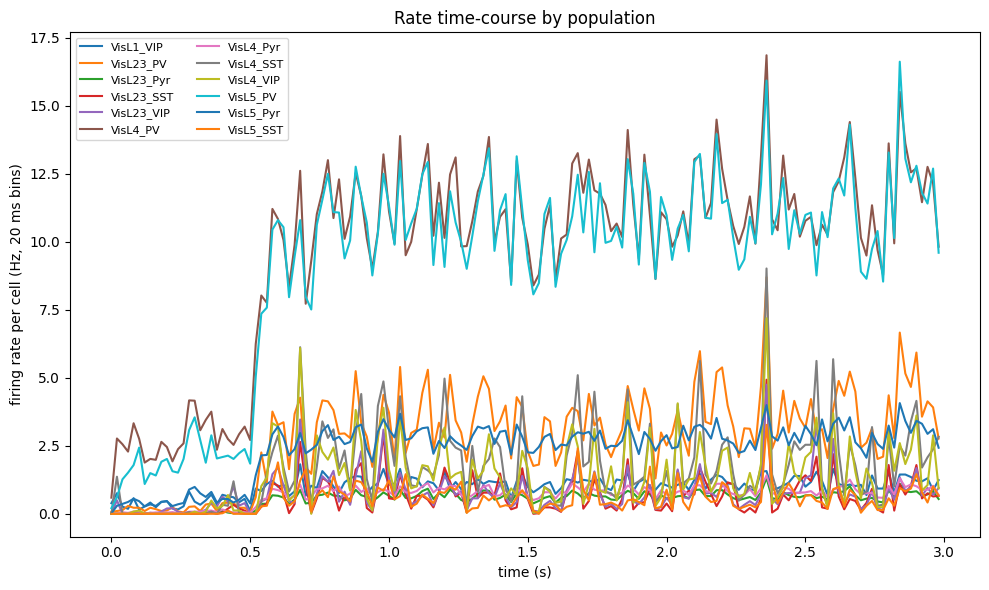

In [22]:
import os
from pathlib import Path
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0. SETTINGS — edit here only if you like
# ------------------------------------------------------------------
ROOT_DIR     = Path(r'D:\WORK\Salvador\doc\Tuning\Allen_model')
SPIKE_FILE   = ROOT_DIR / 'spikes.h5'
NODE_FILE    = ROOT_DIR / 'v1_nodes.csv'

TIME_WINDOWS = [          # (name, start_ms, end_ms) — add / change as needed
    ('grey_pre',   150,   500),
    ('stimulus', 500,  2500),
    #('grey_post', 2500, 3000),
]
BIN_MS       = 20         # time-course bin width
PLOT_MAX_POPS = 12        # only first N pops to keep plots readable (None = all)

# ------------------------------------------------------------------
os.chdir(ROOT_DIR)

# helper: broad cell-class from pop_name ---------------------------------
def classify(pop_name: str) -> str:
    s = pop_name.lower()
    if 'pvalb' in s or re.search(r'\bpv', s):         return 'PV'
    if 'sst'  in s:                                   return 'SST'
    if 'vip'  in s or 'htr3a' in s:                   return 'VIP'
    return 'Pyr'                                      # default excitatory

# 1. node-level metadata -----------------------------------------------
nodes = pd.read_csv(
    NODE_FILE, delim_whitespace=True,
    usecols=['id', 'pop_name', 'location']
)
nodes['type']       = nodes['pop_name'].apply(classify)
nodes['population'] = nodes['location'] + '_' + nodes['type']

cells_per_pop = nodes.groupby('population').size()
gid_to_pop    = dict(zip(nodes['id'], nodes['population']))

# 2. load spike report ---------------------------------------------------
with h5py.File(SPIKE_FILE, 'r') as f:
    ts   = f['spikes']['v1']['timestamps'][...]   # ms
    gids = f['spikes']['v1']['node_ids'][...]

spikes = pd.DataFrame({'gid': gids, 't_ms': ts})
spikes['population'] = spikes['gid'].map(gid_to_pop)

run_duration = spikes['t_ms'].max() / 1000.0  # s

# 3. firing-rate table ---------------------------------------------------
# overall rate
overall_counts = spikes.groupby('population').size()
overall_rate   = (overall_counts / cells_per_pop) / run_duration
rates = pd.DataFrame({'n_cells': cells_per_pop, 'overall_Hz': overall_rate})

# per-window rates
for name, t0, t1 in TIME_WINDOWS:
    mask = (spikes['t_ms'] >= t0) & (spikes['t_ms'] < t1)
    counts = spikes.loc[mask].groupby('population').size()
    win_rate = (counts / cells_per_pop) / ((t1 - t0) / 1e3)
    rates[f'{name}_Hz'] = win_rate                              # aligns by index

# tidy columns & order
rates = (
    rates
    .reset_index()
    .rename(columns={'index': 'population'})
    .sort_values('population')
    .fillna(0)                         # pops silent in a window → 0 Hz
)

print(rates.to_string(index=False))

# 4. rate-time-course per population ------------------------------------
# create 20 ms bins
bin_edges = np.arange(0, spikes['t_ms'].max() + BIN_MS, BIN_MS)
spikes['bin'] = np.searchsorted(bin_edges, spikes['t_ms'], side='right') - 1
bin_dur_s = BIN_MS / 1000.0

timecourse = (
    spikes
    .groupby(['population', 'bin'])
    .size()
    .div(cells_per_pop, level='population')   # per-cell
    .div(bin_dur_s)                           # Hz
    .unstack(fill_value=0)
)

# ----- plot (one trace per population) ---------------------------------
pop_list = timecourse.index[:PLOT_MAX_POPS] if PLOT_MAX_POPS else timecourse.index

plt.figure(figsize=(10, 6))
for i, pop in enumerate(pop_list):
    plt.plot(bin_edges[:-1]/1000.0, timecourse.loc[pop], label=pop)

plt.xlabel('time (s)')
plt.ylabel(f'firing rate per cell (Hz, {BIN_MS} ms bins)')
plt.title('Rate time-course by population')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
